In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import quad

In [2]:
df = pd.read_csv('supernovae.csv')

print(df.to_string()) 

            z        mu  sigma_mu
0     0.50309  42.28445   0.12605
1     0.49480  42.23020   0.11765
2     0.67767  43.38770   0.20560
3     0.86650  43.69685   0.17385
4     0.79857  43.71050   0.17435
5     0.37144  41.63785   0.12450
6     0.35582  41.40915   0.12645
7     0.28360  40.75915   0.10280
8     0.46640  42.56635   0.15870
9     0.94688  43.76155   0.16420
10    0.69315  43.14645   0.24445
11    0.89693  43.75275   0.16645
12    0.78904  43.56880   0.11585
13    0.59027  42.68540   0.16660
14    0.21075  39.99495   0.10525
15    0.85852  43.47370   0.14780
16    0.55875  42.51480   0.13350
17    0.99640  44.04965   0.14080
18    0.58294  42.69385   0.12580
19    0.79656  43.20445   0.15880
20    0.91348  43.72895   0.13735
21    0.94846  44.01675   0.15105
22    0.73362  43.19810   0.15575
23    0.76560  43.45805   0.15490
24    0.98341  44.17800   0.15300
25    0.70064  43.09920   0.17380
26    0.83814  43.50450   0.18070
27    0.37060  41.49010   0.12110
28    0.35858 

In [8]:
# define the mu function
def mu_model(z, omega_m, omega_l, script_M, H_0=70,c=299792.458):
    
    integrand = lambda zp: 1.0 / np.sqrt(omega_m * (1 + zp)**3 + omega_l)
    integral_val, _ = quad(integrand, 0, z)
    
    luminosity_distance_factor = (1.0 + z) * (c / H_0) * integral_val
    
    mu = 5.0 * np.log10(luminosity_distance_factor) + 25.0 + script_M
    
    return mu

In [15]:
# defining the chi squared function
def chi_squared(params, z, mu_each, sigma):
    omega_m, omega_l, m_nuisance = params
    
    mu_model_vectorized = np.vectorize(mu_model)
    mu_pred = mu_model_vectorized(z, omega_m, omega_l, m_nuisance)
    return np.sum(((mu_each - mu_pred) / sigma) ** 2)

In [18]:
# algorithm to reduce chi squared
from scipy.optimize import minimize

initial_guess = [1, 1, 1]  # [omega_m, omega_l, m_nuisance]

z = df['z'].to_numpy()
mu_each = df['mu'].to_numpy()
sigma_mu = df['sigma_mu'].to_numpy()

result = minimize(
    fun=chi_squared,
    x0=initial_guess,
    args=(z, mu_each, sigma_mu),
    method='Nelder-Mead'
)

best_omega_m, best_omega_l, best_m_nuisance = result.x
print(f"Fit: = {best_omega_m}\nomega_l = {best_omega_l}\nm_nuisance = {best_m_nuisance}")

Fit: = 0.5597684994930037
omega_l = 1.4076770763929234
m_nuisance = 0.7296282003002823


In [24]:
# final chi squared value
chi_squared((best_omega_m, best_omega_l, best_m_nuisance), df['z'], df['mu'], df['sigma_mu'])

np.float64(1035.6791576794303)

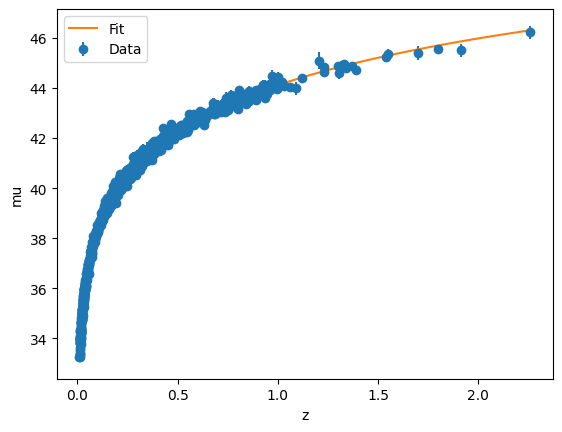

In [23]:
# plot the data and the line
plt.errorbar(df['z'], df['mu'], yerr=df['sigma_mu'], fmt='o', label='Data')
z_fit = np.linspace(df['z'].min(), df['z'].max(), 100)
mu_fit = np.vectorize(mu_model)(z_fit, best_omega_m, best_omega_l, best_m_nuisance)
plt.plot(z_fit, mu_fit, '-', label='Fit')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend()
plt.show()